---
authors:
  - name: Tom Siegl
---

# Linear Regression Basics

## Linear Functions and Errors

You might remember a linear function of the form

$$y = mx+n$$

from school.
It has one argument, $x$, and two constants, $m$ for the slope and $n$ for the intersection with the $y$-axis.

This is what it looks like when we plot it:

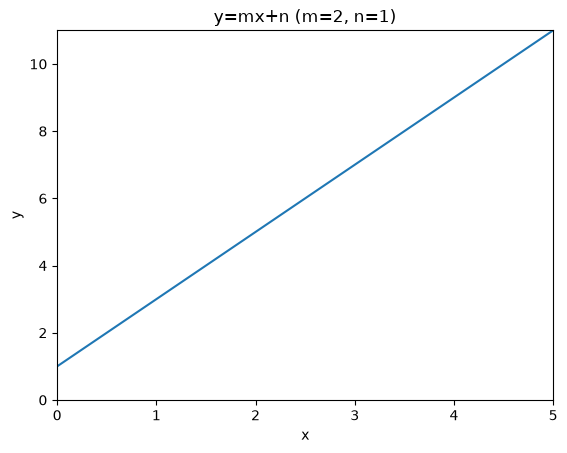

In [1]:
################################
# RUN, THEN COLLAPSE THIS CELL #
################################

import matplotlib.pyplot as plt

m = 2
n = 1

f = lambda x: m*x+n

plt.plot([0, 5], [f(0), f(5)])
plt.xlim(0, 5)
plt.ylim(0, f(5))
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"y=mx+n (m={m}, n={n})")
plt.show()

A linear regression model for a single independent variable is actually the same function, we just write it a little differently as 

$$\hat{y_i} = \hat{\beta_0} + \hat{\beta_1} \cdot x_i.$$

As a linear regression model, this function does not stand alone, but it comes with a dataset $\{(x_i, y_i) \in \mathbb{R}^2\}_{i=1}^{n}$, that it is fitted to.
Fitting here means to select the constants $\hat{\beta_0}$ and $\hat{\beta_1}$, such that the $\hat{y_i}$ is as close to $y_i$ as possible for all $i \in \{1, \dots, n\}$.

In this setting, we call $x$ the independent variable and $y$ the dependent variable, because we assume that its values depend on the values of $x$.
We say that $\hat{y}$ is an estimate of $y$ for any given value of $x$.
Note that the linear regression model does so using only linear operations on $x$.

The following code (skip the plotting function) demonstrates how easy it is to obtain a fitted linear regression model using sklearn given some data.
You can see that the resulting model is really just the linear function you know from school time.
Feel free to temper with the values of `model.coef_` and `model.intercept_` after fitting, to see how the plot and the RSS change.

In [2]:
################################
# RUN, THEN COLLAPSE THIS CELL #
################################

import numpy as np


def plot_iris_model(model, X, y, y_pred, ax):
    # sort X, y and y_pred by X
    sort_idx = np.argsort(X[:, 0])
    X = X[sort_idx, :]
    y = y[sort_idx]
    y_pred = y_pred[sort_idx]
    
    # Plot data and fitted line
    ax.plot(X, y_pred, color="blue", alpha=0.7, label=f"$y={model.coef_[0]:.2f}x+{model.intercept_:.2f}$")
    ax.scatter(X, y, label="Data", color="red", alpha=0.5, zorder=10)

    # Plot residuals
    for i in range(len(X)):
        ax.vlines(X[i], y_pred[i], y[i], color="gray", alpha=0.5, zorder=-10)
    
    ax.set_xlabel("Sepal width (cm)")
    ax.set_ylabel("Petal length (cm)")
    ax.set_title("Linear Fit: Petal Length vs Sepal Width")
    ax.legend()

RSS = 49.76


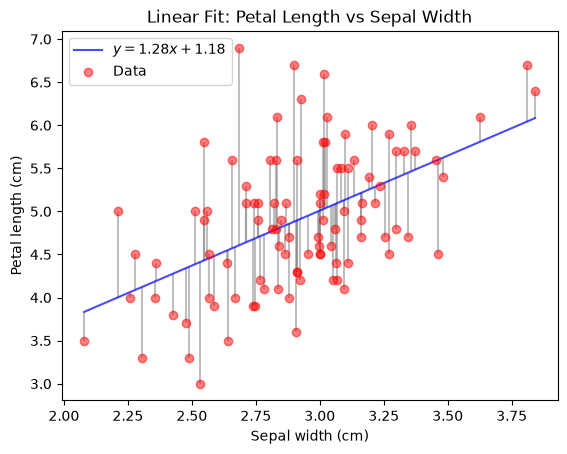

In [3]:
from sklearn.datasets import load_iris
from sklearn.linear_model import LinearRegression


def RSS(y, y_pred):
    return np.sum(np.square(y-y_pred))


np.random.seed(0)

# Load iris data and select values for species Iris-Versicolour and Iris-Virginica
iris = load_iris()
X = iris.data[50:, 1].reshape(-1, 1)  # sepal width
X += np.random.random(X.shape)*0.1    # add some noise for better plotting
y = iris.data[50:, 2]                 # petal length

# Fit linear model
model = LinearRegression()
model.fit(X, y)

# Try some other values here and see how that changes the model and the RSS below.
# model.coef_ = np.array([2.])
# model.intercept_ = 1.

y_pred = model.predict(X)
print(f"RSS = {RSS(y, y_pred):.2f}")

fig, ax = plt.subplots(1, 1)
plot_iris_model(model, X, y, y_pred, ax)
plt.show()

:::{important} Tasks
1. Which of the variables in the formula of the linear regression model are learned when the model is fitted to the dataset?
2. Extend the model formula to a dataset $\{(x_{i1}, x_{i2}, x_{i3}, x_{i4}, y_i) \in \mathbb{R}^5\}_{i=1}^{n}$.
3. Rewrite the extended model formula as a single dot product between two vectors.
4. Define the function that we aim to minimize when fitting a linear regression model to a dataset. (**Hint:** The function is called "RSS" in the slides.)
5. All $x$ variables are defined as real numbers. How would you handle categorical attributes in a dataset?
6. Bonus: What is the most common way to fit a linear regression model in practice?
:::

:::{tip} Your answer
:class:dropdown
1. 
2. 
3. 
4. 
5. 
6. 
:::

We can preprocess the dependent variables in any way we want before passing them to the linear regression model.
This includes applying a mathematical function, which can make the predictions seem nonlinear.
They are still linear w.r.t. the model input (since we still fit a linear model), but the model input might not be linear w.r.t. the originally observed variable anymore.
Note that the nonlinearity is fixed though and cannot be learned.

For example, we could try to fit a linear model on different powers of $x$.

power = 1, RSS = 49.76
power = 2, RSS = 49.76
power = 3, RSS = 49.95
power = 4, RSS = 50.32


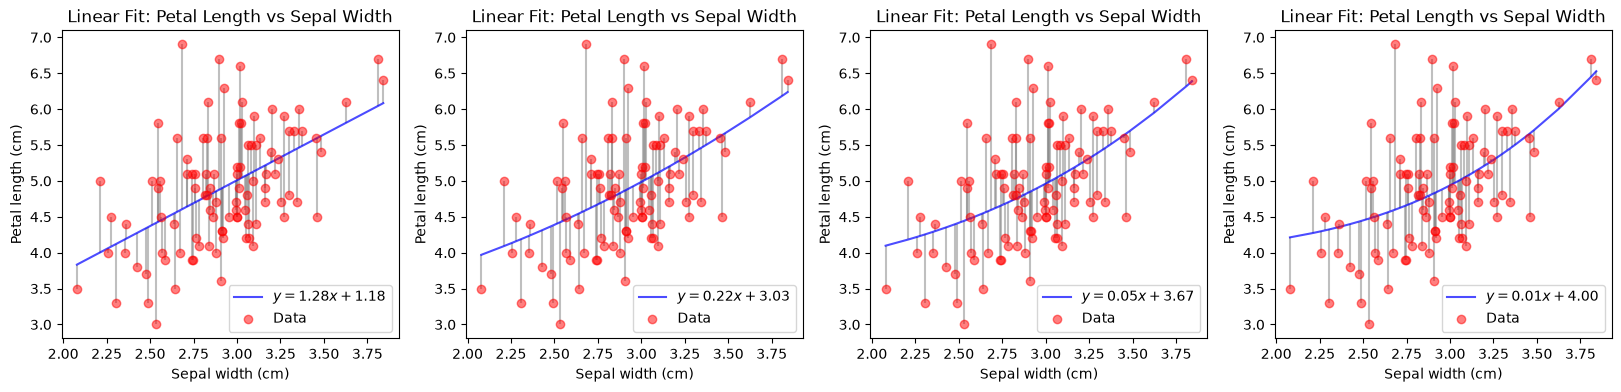

In [4]:
fig, axs = plt.subplots(1, 4, figsize=(20, 4))
for power in range(1, 5):
    power_model = LinearRegression()
    power_model.fit(X**power, y)

    power_y_pred = power_model.predict(X**power)
    print(f"power = {power}, RSS = {RSS(y, power_y_pred):.2f}")

    plot_iris_model(power_model, X, y, power_y_pred, axs[power-1])
plt.show()

To gain some more flexibility w.r.t. the nonlinearity, we can simply add the result of applying many different nonlinear functions on our original $x$.
This is called a basis expansion and it allows our linear model to select from different nonlinearly transformed versions of $x$.

If we apply this idea to our power example from before, we allow the model to create its predictions from a linear combination of different powers.
Thereby we obtain a linear model that effectively learns a polynomial function of fixed degree.

See for yourself:

In [5]:
################################
# RUN, THEN COLLAPSE THIS CELL #
################################

def plot_polynomial_iris_model(model, X, y, y_pred, ax):
    # sort X, y and y_pred by X
    sort_idx = np.argsort(X[:, 0])
    X = X[sort_idx, :]
    y = y[sort_idx]
    y_pred = y_pred[sort_idx]

    X_samples = np.linspace(X.min(), X.max(), 1000).reshape(-1, 1)
    X_samples_powers = np.hstack([X_samples**power for power in range(1, polynomial_degree+1)])
    y_samples = model.predict(X_samples_powers)
    
    # Plot data and fitted line
    ax.plot(X_samples, y_samples, color="blue", alpha=0.7, label="Fitted model")
    ax.scatter(X, y, label="Data", color="red", alpha=0.5, zorder=10)

    # Plot residuals
    for i in range(len(X)):
        ax.vlines(X[i], y_pred[i], y[i], color="gray", alpha=0.5, zorder=-10)

    ax.set_ylim(y.min()*0.9, y.max()*1.1)
    ax.set_xlabel("Sepal width (cm)")
    ax.set_ylabel("Petal length (cm)")
    ax.set_title("Linear Fit: Petal Length vs Sepal Width")
    ax.legend()

intercept = 2.8576043123860027, coefficients = [ 0.00028433  0.00108156  0.00289564  0.00627003  0.01092772  0.01368661
  0.00687824 -0.01127052  0.00329236 -0.00028737]
polynomial degree = 10, RSS = 48.84


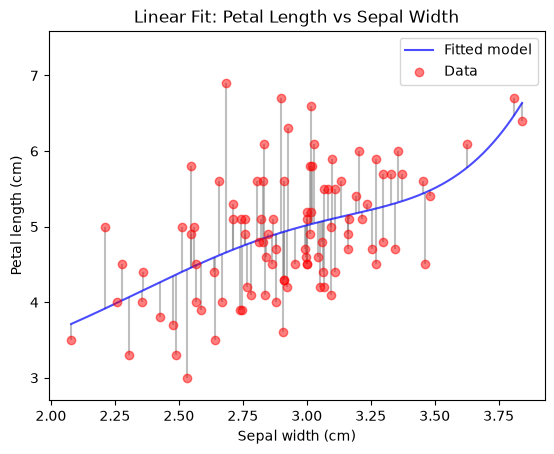

In [6]:
polynomial_degree = 10
X_powers = np.hstack([X**power for power in range(1, polynomial_degree+1)])

polynomial_model = LinearRegression()
polynomial_model.fit(X_powers, y)
print(f"intercept = {polynomial_model.intercept_}, coefficients = {polynomial_model.coef_}")

polynomial_y_pred = polynomial_model.predict(X_powers)
print(f"polynomial degree = {polynomial_degree}, RSS = {RSS(y, polynomial_y_pred):.2f}")

fig, ax = plt.subplots(1, 1)
plot_polynomial_iris_model(polynomial_model, X, y, polynomial_y_pred, ax)

You might have noticed, that the fit of this polynomial model is not as good as one might expect, if you played around with the degree of the polynomial in the last code cell.
This is because the powers in the expanded features increase linearly, which makes features based on high powers very similar to each other.
They get so similar, that they are almost not linearly dependent anymore.
This creates numerical problems when computing the optimal coefficients, limiting them to small values.

This problem can be avoided, by choosing functions that result in less similar variables, such as radial basis functions.

A very simple choice of other functions is the set of indicator functions for a set of distinct intervals (also called bins, which you might know from histograms).
An indicator function returns $1$ if the input lies in a predefined set (the interval in this case), and $0$ otherwise.
So for a given input, the linear model just knows in which interval $x$ lies.
For any single interval, the linear model therefore simply learns to predict the mean of $y$ of all training points in that interval.

This is what such a model would look like on our Iris data:

In [7]:
################################
# RUN, THEN COLLAPSE THIS CELL #
################################


def one_hot_binning(x: np.ndarray, b: int) -> np.ndarray:
    x = x.ravel()
    bins = np.linspace(x.min(), x.max(), b + 1)
    indices = np.digitize(x, bins, right=False) - 1
    indices = np.clip(indices, 0, b - 1)
    one_hot = np.eye(b)[indices]
    return one_hot


def plot_binned_iris_model(model, X, y, y_pred, bins, ax):
    # sort X, y and y_pred by X
    sort_idx = np.argsort(X[:, 0])
    X = X[sort_idx, :]
    y = y[sort_idx]
    y_pred = y_pred[sort_idx]

    X_samples = np.linspace(X.min(), X.max(), 1000).reshape(-1, 1)
    X_samples_binned = one_hot_binning(X_samples, bins)
    y_samples = model.predict(X_samples_binned)
    
    # Plot data and fitted line
    ax.plot(X_samples, y_samples, color="blue", alpha=0.7, label="Fitted model")
    ax.scatter(X, y, label="Data", color="red", alpha=0.5, zorder=10)

    # Plot residuals
    for i in range(len(X)):
        ax.vlines(X[i], y_pred[i], y[i], color="gray", alpha=0.5, zorder=-10)

    ax.set_ylim(y.min()*0.9, y.max()*1.1)
    ax.set_xlabel("Sepal width (cm)")
    ax.set_ylabel("Petal length (cm)")
    ax.set_title("Linear Fit: Petal Length vs Sepal Width")
    ax.legend()

#bins = 10, RSS = 47.75


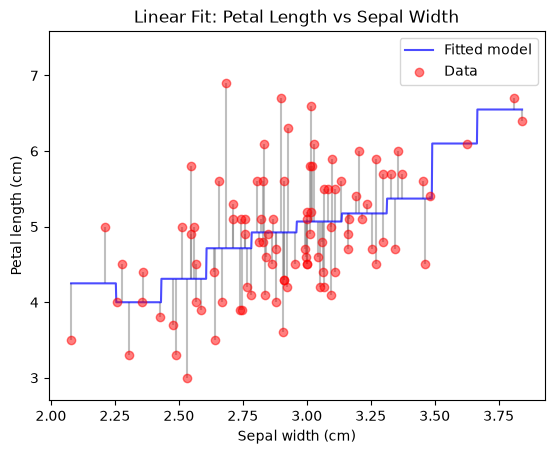

In [8]:
bins = 10
X_binned = one_hot_binning(X, bins)

bins_model = LinearRegression()
bins_model.fit(X_binned, y)

bins_y_pred = bins_model.predict(X_binned)
print(f"#bins = {bins}, RSS = {np.linalg.norm(y-bins_y_pred)**2:.2f}")

fig, ax = plt.subplots(1, 1)
plot_binned_iris_model(bins_model, X, y, bins_y_pred, bins, ax)